In [8]:
import pandas as pd

df = pd.read_csv('insurance.csv')
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [9]:
# Mostrar los datos nulos y duplicados
print(f"Cantidad de datos nulos: {df.isnull().sum().sum()}")
print(f"Cantidad de datos duplicados: {df.duplicated().sum()}")

Cantidad de datos nulos: 0
Cantidad de datos duplicados: 1


In [11]:
# Eliminar datos Duplicados
df_insurance = df.drop_duplicates()
print(f"Cantidad de datos duplicados: {df.duplicated().sum()}")

Cantidad de datos duplicados: 1


In [12]:
# Mostrar metodo info y describe para comprender mejor el DF
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max

In [13]:
# Distribución de los datos únicos
df['children'].unique()

array([0, 1, 3, 2, 5, 4])

<Axes: >

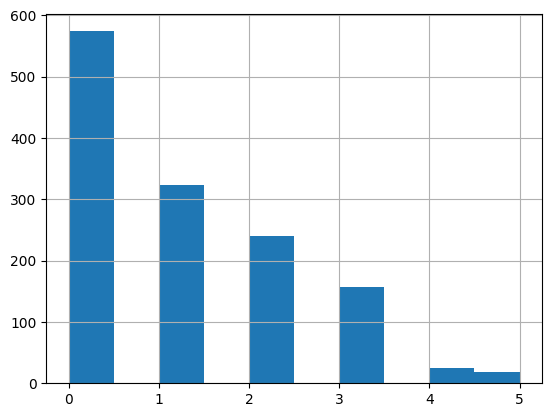

In [14]:
# Histograma para visualizar datos
df['children'].hist()

In [15]:
df['children'] = df['children'].astype('category')

**Preprocesamiento de Datos:**
* Imputar valores faltantes utilizando técnicas adecuadas (media, mediana, moda, imputación avanzada).
* Codificar variables categóricas utilizando One-Hot Encoding.
* Escalar características numéricas utilizando StandardScaler.

# Transformación Pipeline

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# Definimos las columnas de cada tipo
num_features = ['age', 'bmi']
cat_features = ['sex', 'smoker', 'region']
ordinal_features = ['children']

# Configuración de transformación para las características ordinales
ordinal_transformer = OrdinalEncoder(categories=[[0, 1, 2, 3, 4, 5]])

# Configuración de transformación para las características categóricas
cat_transformer = OneHotEncoder(drop='first')  # Evita multicolinealidad eliminando la primera categoría

# Configuración de transformación para las características numéricas
num_transformer = StandardScaler()

# Crear el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('ord', ordinal_transformer, ordinal_features)
    ]
)

# Crear el pipeline con el preprocesador
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Ajustar el pipeline al conjunto de datos (sin la columna objetivo)
X = df.drop('charges', axis=1)
y = df['charges']
pipeline.fit(X)

# Transformar los datos
X_preprocessed = pipeline.transform(X)

# Verificación de la forma del resultado transformado
print(X_preprocessed.shape)

(1338, 8)


In [18]:
# Obtener los nombres de las columnas de las características transformadas
encoded_feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Convertir el resultado a un DataFrame de pandas
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=encoded_feature_names, index=X.index)

In [19]:
# Mostrar datos transformados
print(X_preprocessed_df.head())

   num__age  num__bmi  cat__sex_male  cat__smoker_yes  cat__region_northwest  \
0 -1.438764 -0.453320            0.0              1.0                    0.0   
1 -1.509965  0.509621            1.0              0.0                    0.0   
2 -0.797954  0.383307            1.0              0.0                    0.0   
3 -0.441948 -1.305531            1.0              0.0                    1.0   
4 -0.513149 -0.292556            1.0              0.0                    1.0   

   cat__region_southeast  cat__region_southwest  ord__children  
0                    0.0                    1.0            0.0  
1                    1.0                    0.0            1.0  
2                    1.0                    0.0            3.0  
3                    0.0                    0.0            0.0  
4                    0.0                    0.0            0.0  


# Variable de Interes y

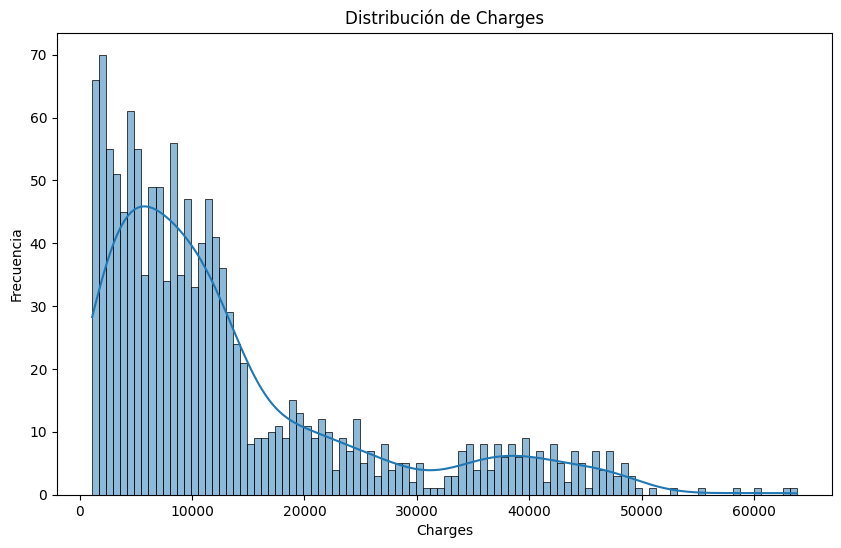

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64
Asimetría (skewness): 1.52
Curtosis: 1.61


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de la distribución de la variable `charges`
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True, bins=100)
plt.title('Distribución de Charges')
plt.xlabel('Charges')
plt.ylabel('Frecuencia')
plt.show()

# Cálculo de estadísticas descriptivas
print(y.describe())

# Cálculo de la asimetría y la curtosis
skewness = y.skew()
kurtosis = y.kurt()

print(f"Asimetría (skewness): {skewness:.2f}")
print(f"Curtosis: {kurtosis:.2f}")

In [21]:
# Cálculo de los percentiles
p33 = y.quantile(0.33)
p66 = y.quantile(0.66)

print(f"Percentil 33 (bajo-medio): {p33:.2f}")
print(f"Percentil 66 (medio-alto): {p66:.2f}")

# Cálculo del percentil 25, 50 (mediana) y 75
q1 = y.quantile(0.25)
q3 = y.quantile(0.75)
iqr = q3 - q1

# Límite superior para considerar valores "muy altos"
upper_bound = q3 + 1.5 * iqr

print(f"Percentil 25 (Q1): {q1:.2f}")
print(f"Percentil 75 (Q3): {q3:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")
print(f"Límite superior para 'muy alto': {upper_bound:.2f}")

Percentil 33 (bajo-medio): 6196.93
Percentil 66 (medio-alto): 12633.38
Percentil 25 (Q1): 4740.29
Percentil 75 (Q3): 16639.91
Rango intercuartílico (IQR): 11899.63
Límite superior para 'muy alto': 34489.35


charges
Bajo        442
Medio       441
Alto        316
Muy alto    139
Name: count, dtype: int64


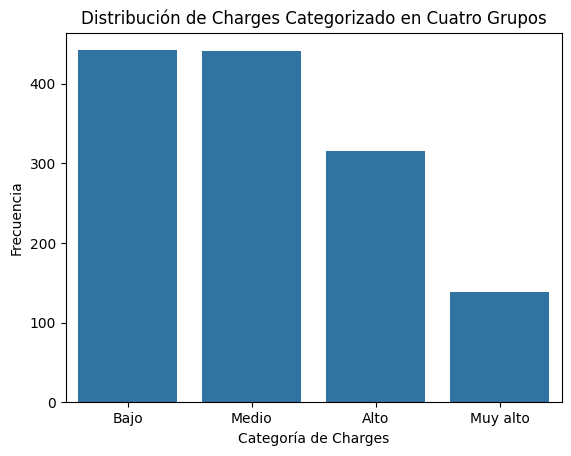

In [22]:
# Crear una variable de respuesta categorizada en cuatro grupos usando el IQR
y_categorized = pd.cut(y, bins=[0, p33, p66, upper_bound, y.max()], labels=['Bajo', 'Medio', 'Alto', 'Muy alto'])

# Verificar la distribución de la nueva variable categorizada
print(y_categorized.value_counts())
sns.countplot(x=y_categorized)
plt.title('Distribución de Charges Categorizado en Cuatro Grupos')
plt.xlabel('Categoría de Charges')
plt.ylabel('Frecuencia')
plt.show()

Percentil 25 (Q1): 4740.29
Mediana (Q2): 9382.03
Percentil 75 (Q3): 16639.91
charges
Bajo          335
Alto          335
Medio-Bajo    334
Medio-Alto    334
Name: count, dtype: int64


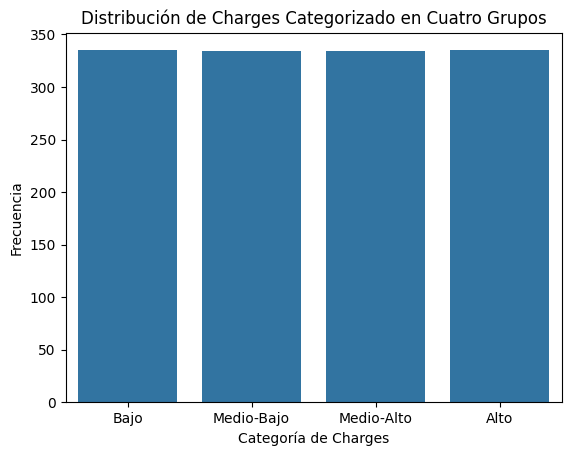

In [23]:
# Cálculo de los cuartiles
q1 = y.quantile(0.25)
q2 = y.quantile(0.50)  # Mediana
q3 = y.quantile(0.75)

print(f"Percentil 25 (Q1): {q1:.2f}")
print(f"Mediana (Q2): {q2:.2f}")
print(f"Percentil 75 (Q3): {q3:.2f}")

# Crear una variable de respuesta categorizada en cuatro grupos usando los cuartiles
y_categorized = pd.cut(y, bins=[0, q1, q2, q3, y.max()], labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'])

# Verificar la distribución de la nueva variable categorizada
print(y_categorized.value_counts())
sns.countplot(x=y_categorized)
plt.title('Distribución de Charges Categorizado en Cuatro Grupos')
plt.xlabel('Categoría de Charges')
plt.ylabel('Frecuencia')
plt.show()

# Modelos Pipeline

**Implementación de Modelos de Clasificación:**
* Entrenar y evaluar al menos tres modelos de clasificación diferentes:  Regresión Logística, K-Nearest Neighbors (KNN), y Árbol de Decisión.
* Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos.

In [24]:
from sklearn.model_selection import train_test_split

# Dividir el dataset en conjuntos de entrenamiento y prueba usando y_categorized
X_train, X_test, y_train, y_test = train_test_split(X, y_categorized, test_size=0.3, random_state=42)

# Verificar la distribución de las clases en y_train e y_test
print("Distribución en y_train:")
print(y_train.value_counts())
print("\nDistribución en y_test:")
print(y_test.value_counts())

Distribución en y_train:
charges
Alto          241
Medio-Bajo    233
Medio-Alto    233
Bajo          229
Name: count, dtype: int64

Distribución en y_test:
charges
Bajo          106
Medio-Bajo    101
Medio-Alto    101
Alto           94
Name: count, dtype: int64


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

# Definición de los modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

# Entrenar y evaluar cada modelo
for model_name, model in models.items():
    # Crear el pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),  # Preprocesador definido previamente
        ('classifier', model)
    ])

    # Entrenar el modelo
    pipeline.fit(X_train, y_train)

    # Predicciones en el conjunto de prueba
    y_pred = pipeline.predict(X_test)

    # Definir etiquetas explícitamente
    labels = y_train.cat.categories

    # Evaluación del modelo
    print(f"\nModelo: {model_name}")
    print("Exactitud:", accuracy_score(y_test, y_pred))
    print("Reporte de clasificación:\n", classification_report(y_test, y_pred, labels=labels, target_names=labels))
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred, labels=labels))


Modelo: Logistic Regression
Exactitud: 0.8333333333333334
Reporte de clasificación:
               precision    recall  f1-score   support

        Bajo       0.91      0.91      0.91       106
  Medio-Bajo       0.77      0.80      0.79       101
  Medio-Alto       0.76      0.84      0.80       101
        Alto       0.92      0.78      0.84        94

    accuracy                           0.83       402
   macro avg       0.84      0.83      0.83       402
weighted avg       0.84      0.83      0.83       402

Matriz de confusión:
 [[96 10  0  0]
 [ 2 81 18  0]
 [ 2  8 85  6]
 [ 6  6  9 73]]

Modelo: K-Nearest Neighbors
Exactitud: 0.7487562189054726
Reporte de clasificación:
               precision    recall  f1-score   support

        Bajo       0.79      0.91      0.84       106
  Medio-Bajo       0.70      0.61      0.66       101
  Medio-Alto       0.70      0.80      0.75       101
        Alto       0.82      0.66      0.73        94

    accuracy                          

# Cross Validation

In [26]:
from sklearn.model_selection import cross_val_score

# Definir los modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

# Realizar validación cruzada y mostrar los resultados
for model_name, model in models.items():
    # Crear el pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),  # Preprocesador definido previamente
        ('classifier', model)
    ])

    # Validación cruzada
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

    # Mostrar resultados
    print(f"\nModelo: {model_name}")
    print(f"Exactitud promedio de validación cruzada: {cv_scores.mean():.4f}")
    print(f"Desviación estándar de validación cruzada: {cv_scores.std():.4f}")
    print(f"Exactitud por partición: {cv_scores}")



Modelo: Logistic Regression
Exactitud promedio de validación cruzada: 0.8269
Desviación estándar de validación cruzada: 0.0130
Exactitud por partición: [0.82978723 0.83957219 0.8342246  0.82887701 0.80213904]

Modelo: K-Nearest Neighbors
Exactitud promedio de validación cruzada: 0.7564
Desviación estándar de validación cruzada: 0.0127
Exactitud por partición: [0.74468085 0.76470588 0.77005348 0.76470588 0.73796791]

Modelo: Decision Tree
Exactitud promedio de validación cruzada: 0.7831
Desviación estándar de validación cruzada: 0.0110
Exactitud por partición: [0.78191489 0.78609626 0.77005348 0.80213904 0.77540107]


# Optimización de Hiperparametros

**Optimización de Hiperparámetros:**
* Implementar GridSearchCV para optimizar los hiperparámetros de los modelos seleccionados.
* Implementar RandomizedSearchCV como método alternativo de optimización.
* Comparar los resultados de GridSearchCV y RandomizedSearchCV para los modelos optimizados.

In [27]:
from sklearn.model_selection import GridSearchCV

# Definición de los hiperparámetros para cada modelo
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1','l2'],
        'classifier__solver': ['liblinear']  # Permite l1 y l2
    },
    'K-Nearest Neighbors': {
        'classifier__n_neighbors': [3, 5, 7, 9, 11],
        'classifier__weights': ['uniform', 'distance'],
        'classifier__metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__criterion': ['gini', 'entropy']
    }
}

# Resultados de búsqueda de hiperparámetros
best_params = {}

# Optimización para cada modelo
for model_name, param_grid in param_grids.items():
    # Crear el pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),  # Preprocesador definido previamente
        ('classifier', models[model_name])  # Modelo a optimizar
    ])

    # Configuración de GridSearchCV
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

    # Ejecutar búsqueda de hiperparámetros
    grid_search.fit(X_train, y_train)

    # Guardar y mostrar los mejores resultados
    best_params[model_name] = grid_search.best_params_
    print(f"\nModelo: {model_name}")
    print(f"Mejores hiperparámetros: {grid_search.best_params_}")
    print(f"Mejor exactitud promedio: {grid_search.best_score_:.4f}")



Modelo: Logistic Regression
Mejores hiperparámetros: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Mejor exactitud promedio: 0.8056

Modelo: K-Nearest Neighbors
Mejores hiperparámetros: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}
Mejor exactitud promedio: 0.8024

Modelo: Decision Tree
Mejores hiperparámetros: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_split': 10}
Mejor exactitud promedio: 0.8440


**Evaluación de Modelos:**
* Evaluar los modelos optimizados utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
* Generar y analizar la matriz de confusión para los modelos optimizados.
* Crear y visualizar la curva ROC para evaluar la capacidad del modelo para distinguir entre clases.


--- Evaluación del Modelo: Logistic Regression ---
Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.92      0.78      0.84        94
  Medio-Bajo       0.83      0.94      0.88       106
  Medio-Alto       0.68      0.77      0.72       101
        Alto       0.72      0.62      0.67       101

    accuracy                           0.78       402
   macro avg       0.79      0.78      0.78       402
weighted avg       0.79      0.78      0.78       402

[[100   6   0   0]
 [ 10  63  28   0]
 [  3  14  78   6]
 [  7   5   9  73]]


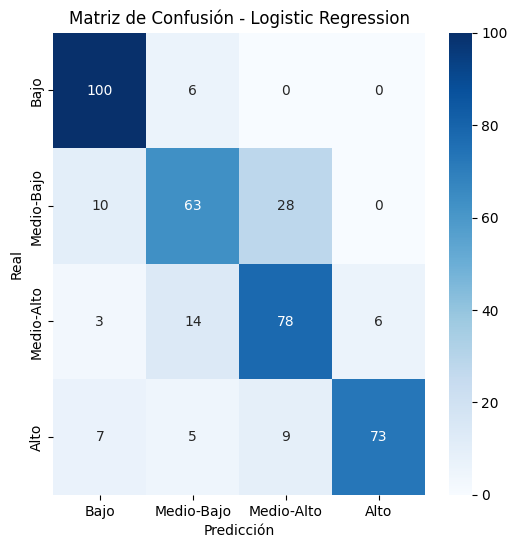

ROC-AUC Promedio (Macro) para Logistic Regression: 0.4156


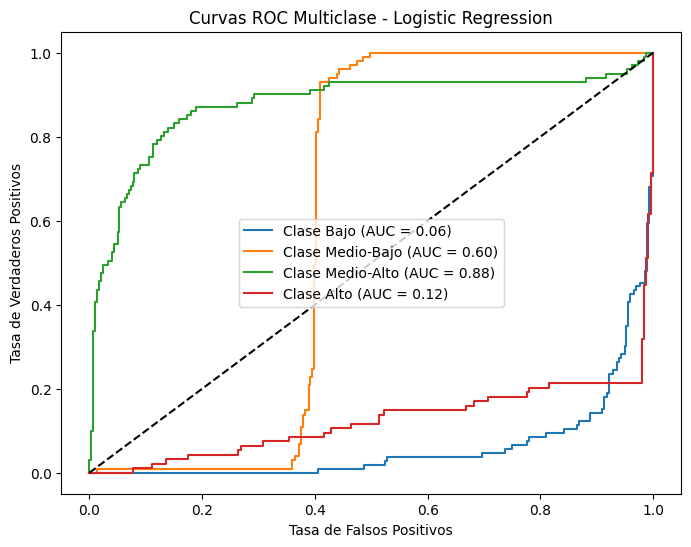


--- Evaluación del Modelo: K-Nearest Neighbors ---
Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.92      0.73      0.82        94
  Medio-Bajo       0.83      0.89      0.86       106
  Medio-Alto       0.78      0.87      0.82       101
        Alto       0.78      0.78      0.78       101

    accuracy                           0.82       402
   macro avg       0.83      0.82      0.82       402
weighted avg       0.83      0.82      0.82       402

[[94 10  0  2]
 [ 7 79 14  1]
 [ 2  8 88  3]
 [10  4 11 69]]


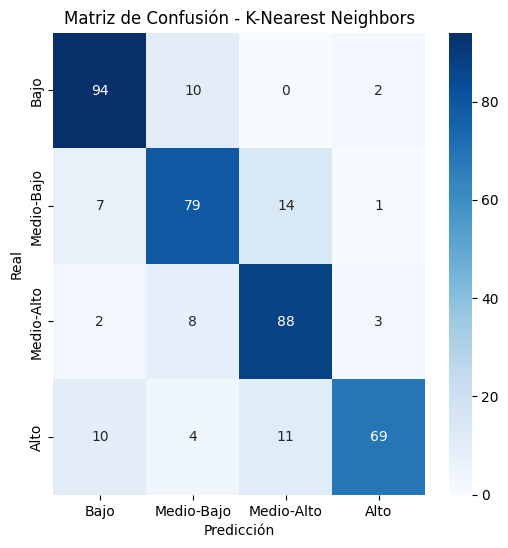


--- Evaluación del Modelo: Decision Tree ---
Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.72      0.79      0.75        94
  Medio-Bajo       0.83      0.88      0.85       106
  Medio-Alto       0.84      0.85      0.85       101
        Alto       0.88      0.74      0.81       101

    accuracy                           0.82       402
   macro avg       0.82      0.81      0.81       402
weighted avg       0.82      0.82      0.82       402

[[93  2  2  9]
 [ 7 75  5 14]
 [ 4  5 86  6]
 [ 8  3  9 74]]


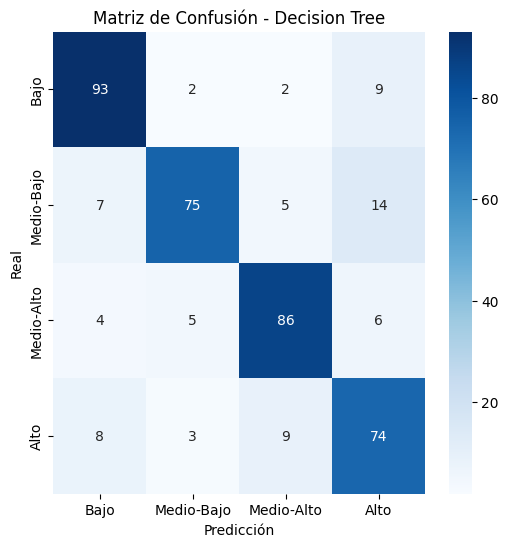

ROC-AUC Promedio (Macro) para Decision Tree: 0.4960


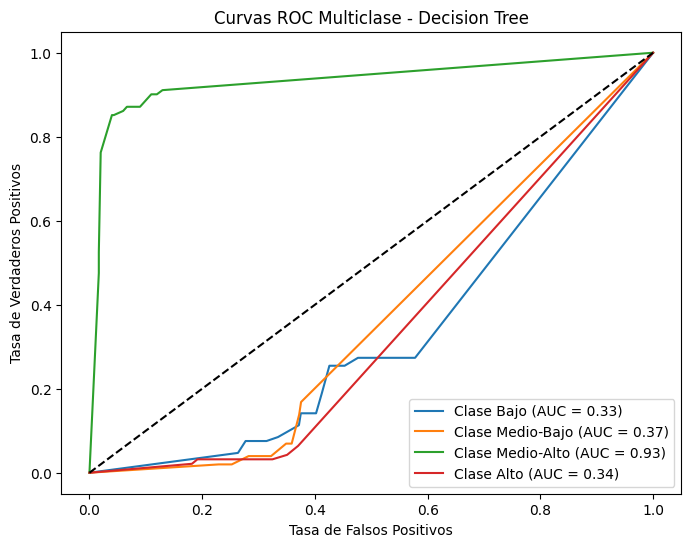

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Binarización de las etiquetas para calcular el ROC-AUC multiclase
y_test_binarized = label_binarize(y_test, classes=y_train.cat.categories)

# Resultados de los modelos optimizados
for model_name, model in models.items():
    print(f"\n--- Evaluación del Modelo: {model_name} ---")

    # Quitar el prefijo 'classifier__' de los mejores hiperparámetros
    best_model_params = {k.replace('classifier__', ''): v for k, v in best_params[model_name].items()}

    # Crear el pipeline con los mejores hiperparámetros de cada modelo
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model.__class__(**best_model_params))  # Aplicar los mejores hiperparámetros sin prefijo
    ])

    # Entrenar el modelo con el conjunto de entrenamiento completo
    pipeline.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = pipeline.predict(X_test)

    # Reporte de clasificación
    print("Reporte de Clasificación:\n", classification_report(y_test, y_pred, target_names=y_train.cat.categories))

    # Matriz de Confusión
    conf_matrix = confusion_matrix(y_test, y_pred, labels=y_train.cat.categories)
    print(conf_matrix)
    plt.figure(figsize=(6, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=y_train.cat.categories, yticklabels=y_train.cat.categories)
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # Calcular el ROC-AUC para cada clase en el enfoque "one-vs-rest"
    if model_name == 'Logistic Regression' or model_name == 'Decision Tree':
        y_pred_proba = pipeline.predict_proba(X_test)

        # Calcular el AUC para cada clase
        roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average="macro", multi_class="ovr")
        print(f"ROC-AUC Promedio (Macro) para {model_name}: {roc_auc:.4f}")

        # Graficar las curvas ROC para cada clase
        plt.figure(figsize=(8, 6))
        for i, class_name in enumerate(y_train.cat.categories):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            plt.plot(fpr, tpr, label=f'Clase {class_name} (AUC = {roc_auc_score(y_test_binarized[:, i], y_pred_proba[:, i]):.2f})')

        plt.plot([0, 1], [0, 1], 'k--')  # Línea diagonal
        plt.title(f'Curvas ROC Multiclase - {model_name}')
        plt.xlabel('Tasa de Falsos Positivos')
        plt.ylabel('Tasa de Verdaderos Positivos')
        plt.legend(loc='best')
        plt.show()



--- Evaluación del Modelo: Logistic Regression ---
Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.83      0.94      0.88       106
  Medio-Bajo       0.72      0.62      0.67       101
  Medio-Alto       0.68      0.77      0.72       101
        Alto       0.92      0.78      0.84        94

    accuracy                           0.78       402
   macro avg       0.79      0.78      0.78       402
weighted avg       0.79      0.78      0.78       402



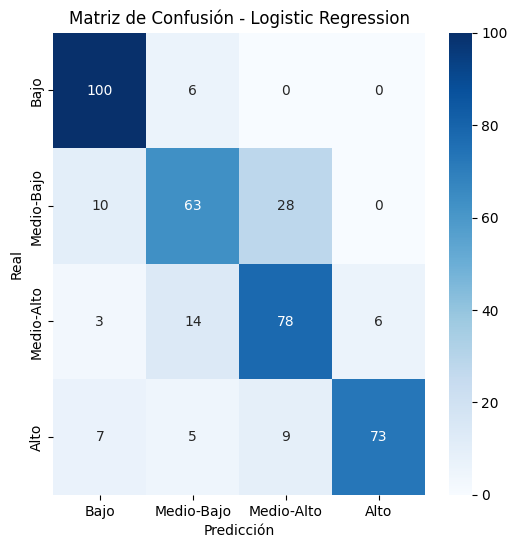

ROC-AUC Promedio (Macro) para Logistic Regression: 0.4156


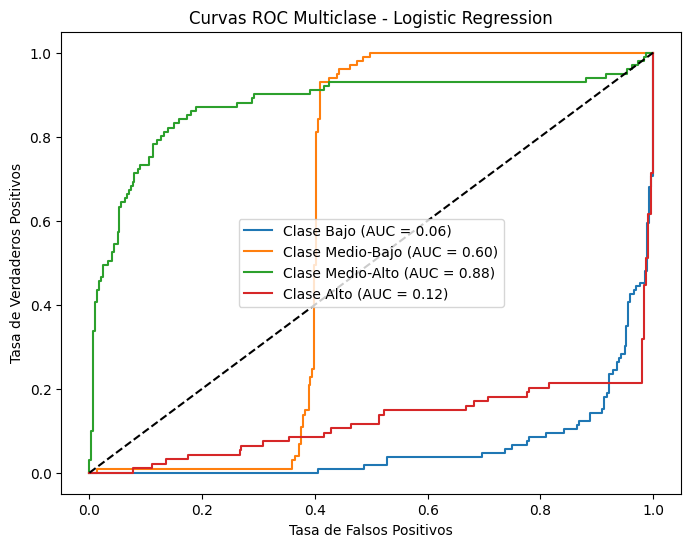


--- Evaluación del Modelo: K-Nearest Neighbors ---
Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.83      0.89      0.86       106
  Medio-Bajo       0.78      0.78      0.78       101
  Medio-Alto       0.78      0.87      0.82       101
        Alto       0.92      0.73      0.82        94

    accuracy                           0.82       402
   macro avg       0.83      0.82      0.82       402
weighted avg       0.83      0.82      0.82       402



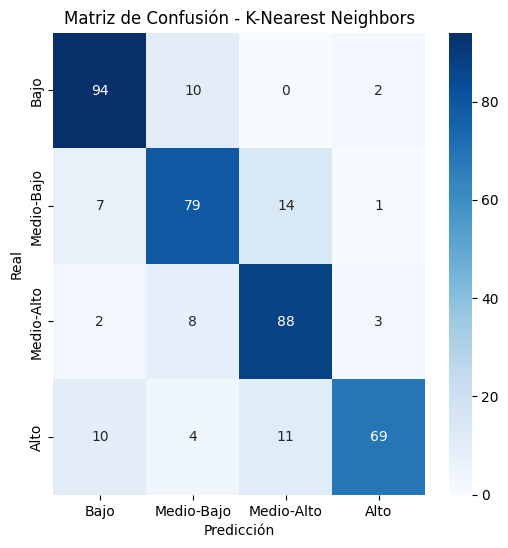


--- Evaluación del Modelo: Decision Tree ---
Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.83      0.88      0.85       106
  Medio-Bajo       0.88      0.74      0.81       101
  Medio-Alto       0.84      0.85      0.85       101
        Alto       0.72      0.79      0.75        94

    accuracy                           0.82       402
   macro avg       0.82      0.81      0.81       402
weighted avg       0.82      0.82      0.82       402



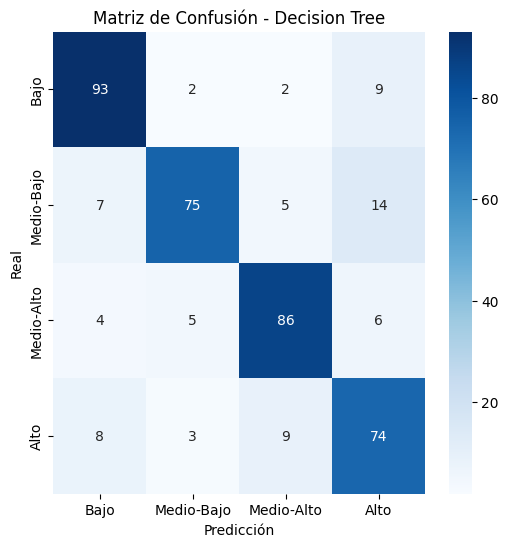

ROC-AUC Promedio (Macro) para Decision Tree: 0.4960


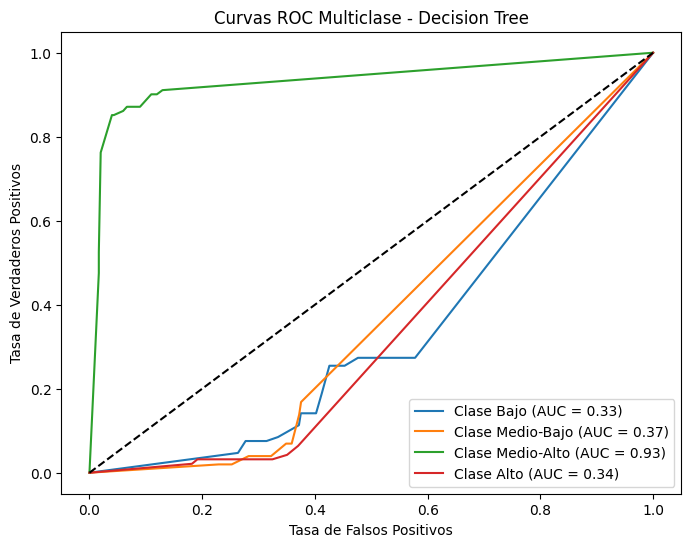

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Binarización de las etiquetas para calcular el ROC-AUC multiclase
y_test_binarized = label_binarize(y_test, classes=y_train.cat.categories)

# Resultados de los modelos optimizados
for model_name, model in models.items():
    print(f"\n--- Evaluación del Modelo: {model_name} ---")

    # Quitar el prefijo 'classifier__' de los mejores hiperparámetros
    best_model_params = {k.replace('classifier__', ''): v for k, v in best_params[model_name].items()}

    # Crear el pipeline con los mejores hiperparámetros de cada modelo
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model.__class__(**best_model_params))  # Aplicar los mejores hiperparámetros sin prefijo
    ])

    # Entrenar el modelo con el conjunto de entrenamiento completo
    pipeline.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = pipeline.predict(X_test)

    # Reporte de clasificación
    print("Reporte de Clasificación:\n", classification_report(y_test, y_pred, labels=y_train.cat.categories, target_names=y_train.cat.categories))

    # Matriz de Confusión
    conf_matrix = confusion_matrix(y_test, y_pred, labels=y_train.cat.categories)
    plt.figure(figsize=(6, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=y_train.cat.categories, yticklabels=y_train.cat.categories)
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # Calcular el ROC-AUC para cada clase en el enfoque "one-vs-rest"
    if model_name == 'Logistic Regression' or model_name == 'Decision Tree':
        y_pred_proba = pipeline.predict_proba(X_test)

        # Calcular el AUC para cada clase
        roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average="macro", multi_class="ovr")
        print(f"ROC-AUC Promedio (Macro) para {model_name}: {roc_auc:.4f}")

        # Graficar las curvas ROC para cada clase
        plt.figure(figsize=(8, 6))
        for i, class_name in enumerate(y_train.cat.categories):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            plt.plot(fpr, tpr, label=f'Clase {class_name} (AUC = {roc_auc_score(y_test_binarized[:, i], y_pred_proba[:, i]):.2f})')

        plt.plot([0, 1], [0, 1], 'k--')  # Línea diagonal
        plt.title(f'Curvas ROC Multiclase - {model_name}')
        plt.xlabel('Tasa de Falsos Positivos')
        plt.ylabel('Tasa de Verdaderos Positivos')
        plt.legend(loc='best')
        plt.show()



--- Evaluación del Modelo: Logistic Regression ---
Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.83      0.94      0.88       106
  Medio-Bajo       0.72      0.62      0.67       101
  Medio-Alto       0.68      0.77      0.72       101
        Alto       0.92      0.78      0.84        94

    accuracy                           0.78       402
   macro avg       0.79      0.78      0.78       402
weighted avg       0.79      0.78      0.78       402



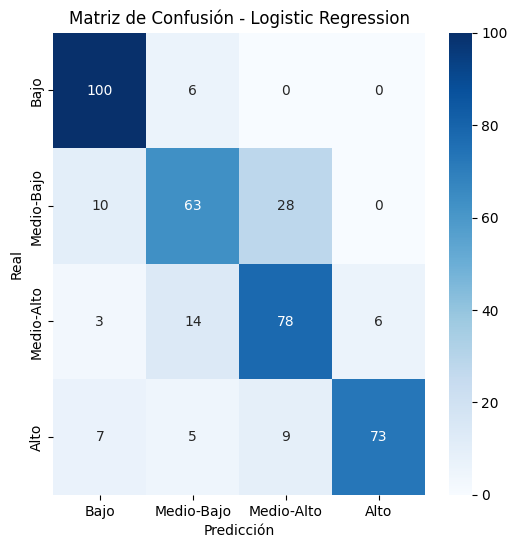

ROC-AUC Promedio (Macro) para Logistic Regression: 0.4156


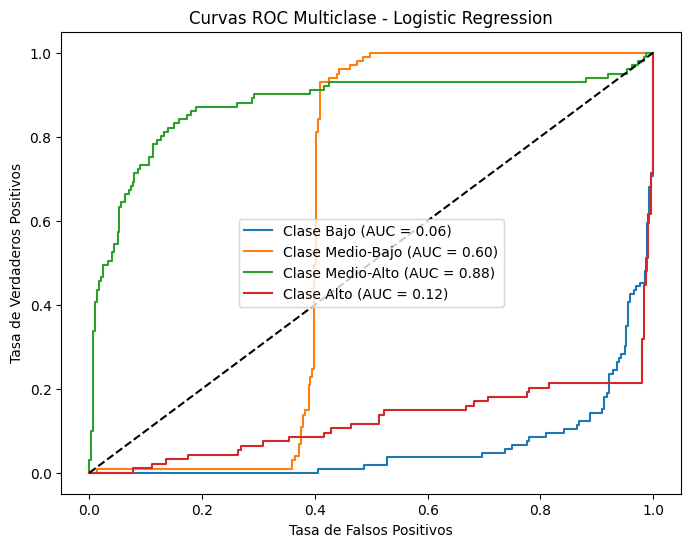


--- Evaluación del Modelo: K-Nearest Neighbors ---
Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.83      0.89      0.86       106
  Medio-Bajo       0.78      0.78      0.78       101
  Medio-Alto       0.78      0.87      0.82       101
        Alto       0.92      0.73      0.82        94

    accuracy                           0.82       402
   macro avg       0.83      0.82      0.82       402
weighted avg       0.83      0.82      0.82       402



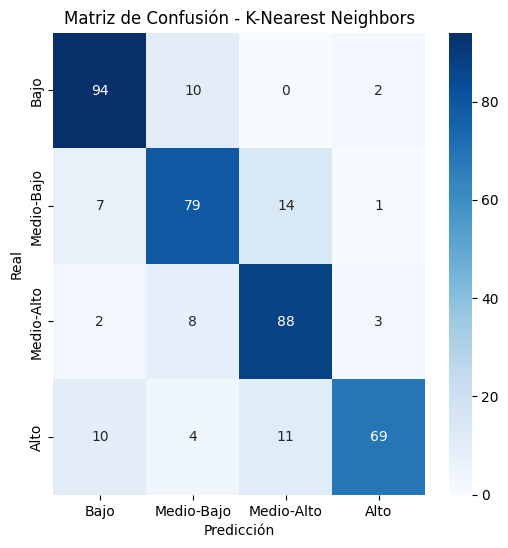

ROC-AUC Promedio (Macro) para K-Nearest Neighbors: 0.5144


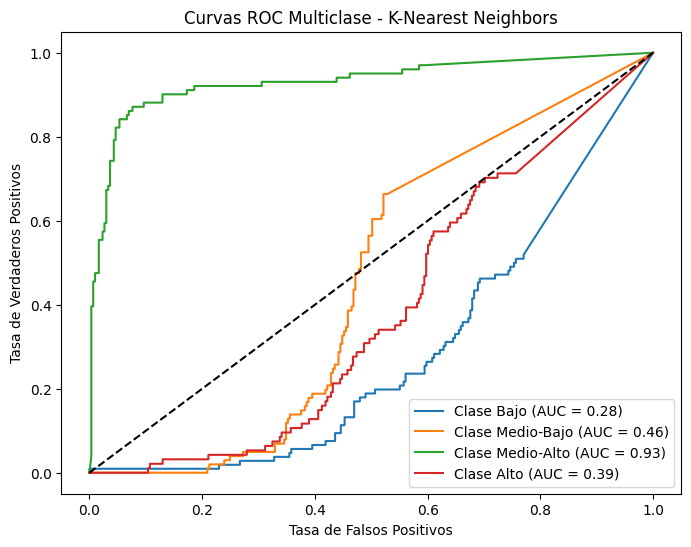


--- Evaluación del Modelo: Decision Tree ---
Reporte de Clasificación:
               precision    recall  f1-score   support

        Bajo       0.83      0.88      0.85       106
  Medio-Bajo       0.88      0.74      0.81       101
  Medio-Alto       0.84      0.85      0.85       101
        Alto       0.72      0.79      0.75        94

    accuracy                           0.82       402
   macro avg       0.82      0.81      0.81       402
weighted avg       0.82      0.82      0.82       402



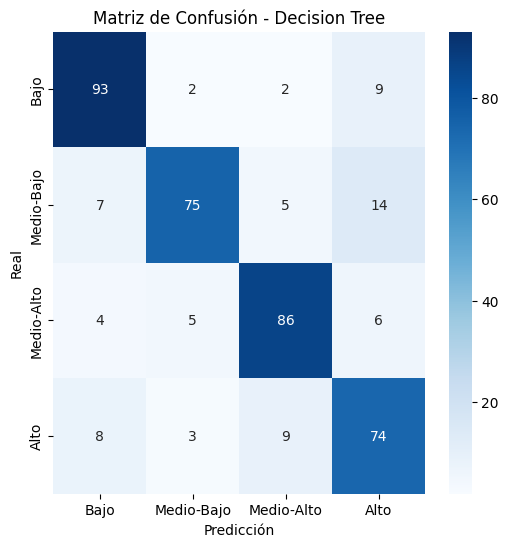

ROC-AUC Promedio (Macro) para Decision Tree: 0.4960


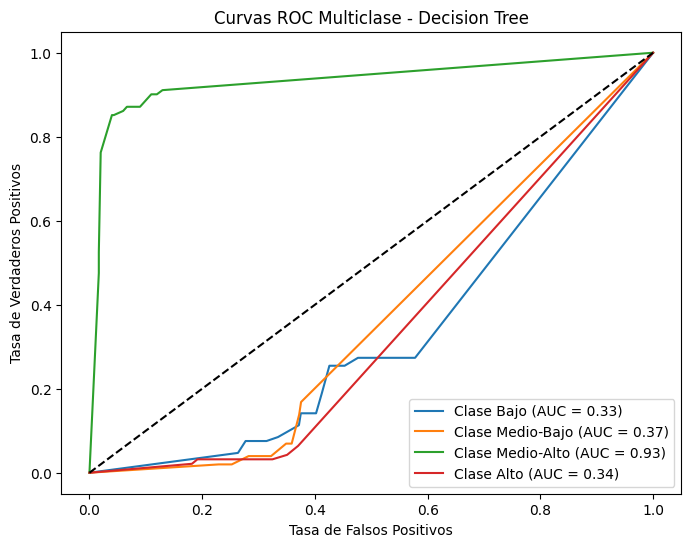

In [30]:
# Evaluación y curvas ROC-AUC solo si el modelo tiene predict_proba()
for model_name, model in models.items():
    print(f"\n--- Evaluación del Modelo: {model_name} ---")

    # Quitar el prefijo 'classifier__' de los mejores hiperparámetros
    best_model_params = {k.replace('classifier__', ''): v for k, v in best_params[model_name].items()}

    # Crear el pipeline con los mejores hiperparámetros de cada modelo
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model.__class__(**best_model_params))  # Aplicar los mejores hiperparámetros sin prefijo
    ])

    # Entrenar el modelo con el conjunto de entrenamiento completo
    pipeline.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = pipeline.predict(X_test)

    # Reporte de clasificación
    print("Reporte de Clasificación:\n", classification_report(y_test, y_pred, labels=y_train.cat.categories, target_names=y_train.cat.categories))

    # Matriz de Confusión
    conf_matrix = confusion_matrix(y_test, y_pred, labels=y_train.cat.categories)
    plt.figure(figsize=(6, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=y_train.cat.categories, yticklabels=y_train.cat.categories)
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # Calcular el ROC-AUC solo si predict_proba() está disponible
    if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
        y_pred_proba = pipeline.predict_proba(X_test)

        # Calcular el AUC para cada clase
        roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average="macro", multi_class="ovr")
        print(f"ROC-AUC Promedio (Macro) para {model_name}: {roc_auc:.4f}")

        # Graficar las curvas ROC para cada clase
        plt.figure(figsize=(8, 6))
        for i, class_name in enumerate(y_train.cat.categories):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            plt.plot(fpr, tpr, label=f'Clase {class_name} (AUC = {roc_auc_score(y_test_binarized[:, i], y_pred_proba[:, i]):.2f})')

        plt.plot([0, 1], [0, 1], 'k--')  # Línea diagonal
        plt.title(f'Curvas ROC Multiclase - {model_name}')
        plt.xlabel('Tasa de Falsos Positivos')
        plt.ylabel('Tasa de Verdaderos Positivos')
        plt.legend(loc='best')
        plt.show()
    else:
        print(f"El modelo {model_name} no tiene el método predict_proba(), por lo que no se puede calcular el ROC-AUC.")
